<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/05_29_librosa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import librosa
import librosa.display

In [2]:
import os
print(os.getcwd())  # 현재 코드가 실행 중인 절대 경로 출력

/content


In [3]:

!mkdir -p /content/data/mini_speech_commands

# 미니 스피치 커맨드 데이터셋 다운로드 (약 182MB)
!wget -O /content/mini_speech_commands.zip http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip

!unzip -q /content/mini_speech_commands.zip -d /content/data/mini_speech_commands

!rm /content/mini_speech_commands.zip

print("압축 해제 완료!")

--2026-05-30 08:58:00--  http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.203.207, 74.125.199.207, 142.251.188.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.203.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182082353 (174M) [application/zip]
Saving to: ‘/content/mini_speech_commands.zip’

/content/mini_speec 100%[===================>] 173.65M   247MB/s    in 0.7s    

2026-05-30 08:58:01 (247 MB/s) - ‘/content/mini_speech_commands.zip’ saved [182082353/182082353]

압축 해제 완료!


In [4]:
import torch
import torchaudio
import torchaudio.transforms as T

file_path = '/content/data/mini_speech_commands/mini_speech_commands/down/004ae714_nohash_0.wav'


try:
    # y 데이터
    # sr 초당 분할 수
    y, sr = torchaudio.load(file_path)
    # 인덱스 제거
    y = y.squeeze(0)
    print("오디오 파일 로드")

except Exception as e:
    print("로드 실패!")
    print(e)

# 사람 귀에 잘 들리는 핵심 주파수만 골라 변환
mel_transform = T.MelSpectrogram(
    sample_rate=sr,
    n_fft=1024,
    hop_length=512,
    n_mels=64

    # sample_rate 주파수
    # n_fft       한 번에 읽을 데이터 개수
    # hop_length  한 번 이동량
    # n_mels      높이 제한
)
# y 데이터 변환
S = mel_transform(y)
print("멜-스펙트로그램 생성 완료!")

# power 소리에너지를 db 데시벨로 변환
# AmplitudeToDB : 소리 데시벨 변환기
# stype=power : 입력 데이터 에너지
# top_db=80.0 : 최고 데시벨 80
power_to_db_transform = T.AmplitudeToDB(stype='power', top_db=80.0)
# S 멜-스펠트로그램 데시벨 변환
S_dB = power_to_db_transform(S)
# 최대 크기를 0으로
# 소리 볼륨을 무시하고 형태만 보겠다
S_dB = S_dB - torch.max(S_dB)

오디오 파일 로드
멜-스펙트로그램 생성 완료!


In [5]:
mel_transform = T.MelSpectrogram(
    sample_rate=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128,
    f_max=8000.0

    # f_max=8000.0 사람 핵심음역대만 남기겠다.
)

S = mel_transform(y)

In [6]:
power_to_db_transform = T.AmplitudeToDB(stype='power', top_db=80.0)

S_dB = power_to_db_transform(S)
S_dB = S_dB - torch.max(S_dB)

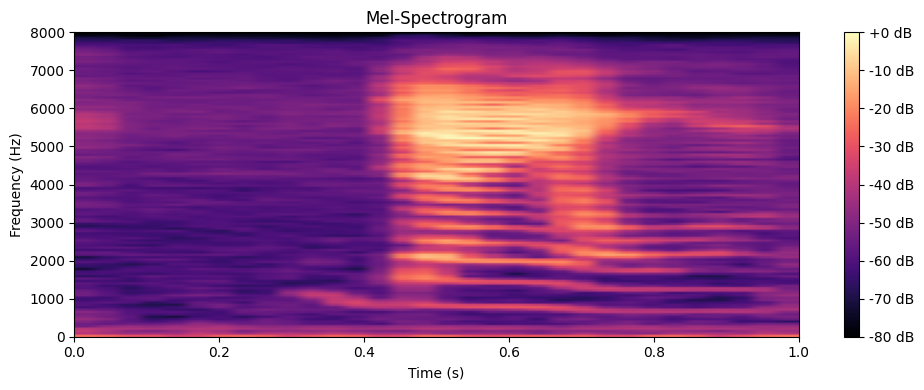

In [7]:
import matplotlib.pyplot as plt
# detach : 순수 데이터만 사용
# cpu    : gpu에서 동작하는 numpy를 사용하기위해 cpu를 사용
# numpy  : numpy로 변환
S_dB_np = S_dB.detach().cpu().numpy()

# figure              : 시각화
# figsize(가로, 세로) : 크기
plt.figure(figsize=(10, 4))

# imshow : 출력
plt.imshow(
    S_dB_np,
    aspect='auto',
    origin='lower',
    cmap='magma',
    extent=[0, y.shape[-1] / sr, 0, 8000] # [x_min, x_max, y_min, y_max] fmax=8000 반영

    # aspect  : 크기조절
    # origin  : 시작위치 설정
    # cmap    : 색
    # extent  : 눈금 설정
    # y.shape[-1] / sr  : 전체데이터/샘플링 비율=실제 길이
)


plt.title('Mel-Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

lines = plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [8]:
from pathlib import Path
import torchaudio


DATASET_PATH = '/content/data/mini_speech_commands/mini_speech_commands'


data_dir = Path(DATASET_PATH)


wav_files = list(data_dir.rglob('*.wav'))

print(f"찾아낸 총 오디오 파일 개수: {len(wav_files)}개")

if len(wav_files) > 0:
    sample_file_path = wav_files[0]
    y, sr = torchaudio.load(sample_file_path)
    print(f"샘플 파일 로드 성공! 파일명: {sample_file_path.name}")
    print(f"Tensor 형태: {y.shape}, Sample Rate: {sr}")

찾아낸 총 오디오 파일 개수: 8000개
샘플 파일 로드 성공! 파일명: 58df33b5_nohash_1.wav
Tensor 형태: torch.Size([1, 16000]), Sample Rate: 16000


In [9]:
import numpy as np

commands = np.array([item.name for item in data_dir.iterdir() if item.is_dir() and not item.name.startswith('.')])
# 하위폴더 중에서 하위폴더이고 .으로 시작하는 폴더(숨김폴더)가 아닌 이름을 배열로 commands에 저장
print("클래스 목록:", commands)

클래스 목록: ['stop' 'down' 'yes' 'up' 'no' 'go' 'left' 'right']


In [10]:
num_classes = len(commands)
num_classes

8

In [11]:
filenames = [str(file) for file in data_dir.glob('*/*.wav')]

print("총 파일 개수:", len(filenames))

총 파일 개수: 8000


In [12]:
num_samples = len(filenames)
num_samples

8000

In [13]:
import random

random.seed(42)
shuffled_files = filenames.copy()
random.shuffle(shuffled_files)

train_files = shuffled_files[:int(0.8 * num_samples)]
val_files = shuffled_files[int(0.8 * num_samples):int(0.9 * num_samples)]
test_files = shuffled_files[int(0.9 * num_samples):]

print(f'학습용 샘플 수 : {len(train_files)}')
print(f'검증용 샘플 수 : {len(val_files)}')
print(f'테스트용 샘플 수 : {len(test_files)}')

학습용 샘플 수 : 6400
검증용 샘플 수 : 800
테스트용 샘플 수 : 800


In [14]:
# 클래스 이름을 인덱스로 맵핑하는 딕셔너리 생성
# ['down', 'go', 'left', ...] -> {'down': 0, 'go': 1, 'left': 2, ...}
command_to_index = {command: i for i, command in enumerate(commands)}


# key: 찾고자 하는 명령어 문자열
# default_value=-1: 딕셔너리에 없는 명령어일 경우 -1 반환
def lookup_table(key):
    return command_to_index.get(key, -1)

print("down의 인덱스:", lookup_table('down'))
print("없는 단어의 인덱스:", lookup_table('hello'))

down의 인덱스: 1
없는 단어의 인덱스: -1


In [15]:
import torch
import torchaudio
import torchaudio.transforms as T



# 데이터 길이 표준화 (1초 = 16000 샘플 고정)
target_length = 16000

# 멜 스펙트로그램 추출
# librosa의 n_fft=255는 파이토치에서 홀수 윈도우 크기 오류가 날 수 있어
# 보통 256으로 매칭하는 것이 안전하고 성능이 좋다.
mel_transform = T.MelSpectrogram(
    sample_rate=target_length,
    n_mels=32,
    n_fft=256,
    hop_length=128,
)


power_to_db_transform = T.AmplitudeToDB(stype='power', top_db=80.0)

def process_audio_pytorch(file_path):
    """
    개별 오디오 파일을 읽고 멜-스펙트로그램으로 변환하는 파이토치용 전처리 함수
    file_path: 문자열(str) 또는 Path 객체 형태의 파일 경로
    """
    y, _ = torchaudio.load(file_path)

    current_length = y.shape[1]


    if current_length < target_length:
        # 부족한 부분을 뒤쪽에 0으로 채워줌
        pad_size = target_length - current_length
        y = torch.nn.functional.pad(y, (0, pad_size))
    else:
        # 16000 샘플보다 길면 자름
        y = y[:, :target_length]

    mel_spec = mel_transform(y)
    log_mel_spec = power_to_db_transform(mel_spec)
    log_mel_spec = log_mel_spec - torch.max(log_mel_spec)

    log_mel_spec = log_mel_spec.to(torch.float32)

    return log_mel_spec

In [16]:
import os
from pathlib import Path
import torch
from torch.utils.data import Dataset

class SpeechCommandDataset(Dataset):
    def __init__(self, filenames, command_to_index):
        self.filenames = filenames
        self.command_to_index = command_to_index

    def __len__(self):
        # 데이터셋의 총 샘플 개수 반환
        return len(self.filenames)

    def __getitem__(self, idx):
        # 파일 경로 가져오기 및 Path 객체 변환 (경로 처리를 쉽게 하기 위함)
        file_path = Path(self.filenames[idx])

        # 파일 경로에서 라벨(폴더명) 추출
        label_str = file_path.parent.name

        # 딕셔너리를 이용해 문자열 라벨을 정수 인덱스로 변환
        label_id = self.command_to_index.get(label_str, -1)
        label_id = torch.tensor(label_id, dtype=torch.long) # 파이토치 정수형 텐서로 변환

        # 오디오 전처리 수행
        log_mel = process_audio_pytorch(file_path)

        # 오디오 크기를 125로 조정
        if log_mel.shape[2] < 126:
            pad_size = 126 - log_mel.shape[2]
            log_mel = torch.nn.functional.pad(log_mel, (0, pad_size))
        else:
            log_mel = log_mel[:, :, :126]

        return log_mel, label_id

In [17]:
import torch
from torch.utils.data import DataLoader

BATCH_SIZE = 64

def build_pipeline_pytorch(files, command_to_index, is_train=False):
    """
    files: 오디오 파일 경로 리스트
    command_to_index: 클래스 맵핑 딕셔너리
    is_train: 학습용 데이터셋 여부 (셔플 및 드롭 설정)
    """

    dataset = SpeechCommandDataset(files, command_to_index)

    # 데이터 로더 정의
    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=is_train,
        drop_last=is_train,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False

        # shuffle         : 훈련일 때 셔플
        # drop_last       : 훈련일 때 남는 거 버림
        # num_workers cpu : 코어 2개 사용
        # pin_memory      : 메모리 고정
        # persistent_workers : 에폭 끝날때마다 worker를 없애지 않고 다시 사용
    )

    return dataloader

In [18]:
# 학습용 데이터 파이프라인 (셔플 ON, 자투리 배치 제거 ON)
train_loader = build_pipeline_pytorch(train_files, command_to_index, is_train=True)

# 검증용 데이터 파이프라인 (셔플 OFF, 모든 데이터 유지)
val_loader = build_pipeline_pytorch(val_files, command_to_index, is_train=False)

# 테스트 데이터 파이프라인 (셔플 OFF, 모든 데이터 유지)
test_loader = build_pipeline_pytorch(test_files, command_to_index, is_train=False)

print(f"학습용 데이터셋 배치 수: {len(train_loader)}개")
print(f"검증용 데이터셋 배치 수: {len(val_loader)}개")
print(f"테스트 데이터셋 배치 수: {len(test_loader)}개")

학습용 데이터셋 배치 수: 100개
검증용 데이터셋 배치 수: 13개
테스트 데이터셋 배치 수: 13개


In [19]:

import torch.nn as nn

class SpeechCommandCNN(nn.Module):
    def __init__(self, num_classes):
        super(SpeechCommandCNN, self).__init__()


        self.features = nn.Sequential(

            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.3),


            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4),


            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64 * 4 * 15, out_features=1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(in_features=1024, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(in_features=256, out_features=64),
            nn.ReLU(),

            nn.Linear(in_features=64, out_features=num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [20]:
import torch.optim as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = SpeechCommandCNN(num_classes=num_classes).to(device)


optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


criterion = nn.CrossEntropyLoss()

cpu


In [21]:
# 1. 라이브러리가 설치되어 있지 않다면 먼저 설치
# !pip install torchsummary

from torchsummary import summary

summary(model, input_size=(1, 32, 126))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 16, 32, 126]             160
       BatchNorm2d-2          [-1, 16, 32, 126]              32
              ReLU-3          [-1, 16, 32, 126]               0
         MaxPool2d-4           [-1, 16, 16, 63]               0
           Dropout-5           [-1, 16, 16, 63]               0
            Conv2d-6           [-1, 32, 16, 63]           4,640
       BatchNorm2d-7           [-1, 32, 16, 63]              64
              ReLU-8           [-1, 32, 16, 63]               0
         MaxPool2d-9            [-1, 32, 8, 31]               0
          Dropout-10            [-1, 32, 8, 31]               0
           Conv2d-11            [-1, 64, 8, 31]          18,496
      BatchNorm2d-12            [-1, 64, 8, 31]             128
             ReLU-13            [-1, 64, 8, 31]               0
        MaxPool2d-14            [-1, 64

In [22]:
import torch
from tqdm.auto import tqdm
import os


os.makedirs('model', exist_ok=True)
model_file_name = 'model/project6_Sound.pt'


epochs = 1000
patience = 30
best_val_loss = float('inf')
patience_counter = 0

history = {
    'loss': [], 'accuracy': [],
    'val_loss': [], 'val_accuracy': []
}


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

epoch_progress = tqdm(range(epochs), desc="Epochs", unit="epoch")

for epoch in epoch_progress:

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()               # 그래디언트 초기화
        outputs = model(batch_X)            # 순전파 예측
        loss = criterion(outputs, batch_y)  # 손실 계산
        loss.backward()                     # 역전파 그래디언트 계산
        optimizer.step()                    # 가중치 업데이트

        train_loss += loss.item() * batch_X.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == batch_y).sum().item()
        train_total += batch_y.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_y.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total


    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)


    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        local_path = "/content/temp_model.pth"
        torch.save(model.state_dict(), local_path)
    else:
        patience_counter += 1


    epoch_progress.set_postfix({
        'loss': f"{epoch_train_loss:.4f}",
        'acc': f"{epoch_train_acc:.4f}",
        'val_loss': f"{epoch_val_loss:.4f}",
        'val_acc': f"{epoch_val_acc:.4f}"
    })


    # atience 기준을 넘으면 조기 종료
    if patience_counter >= patience:
        epoch_progress.write(f"조기종료 : (Epoch {epoch+1}에서 학습 중단)")
        break


Epochs:   0%|          | 0/1000 [00:00<?, ?epoch/s]

조기종료 : (Epoch 102에서 학습 중단)


In [24]:
hist = history

# 케라스 버전에 맞춰 존재하는 키 확인 후 출력
print("훈련 손실값 (Loss):", hist.get('loss'))
print("훈련 정확도 (Accuracy):", hist.get('accuracy') or hist.get('acc'))
print("검증 손실값 (Val Loss):", hist.get('val_loss'))
print("검증 정확도 (Val Accuracy):", hist.get('val_accuracy') or hist.get('val_acc'))

훈련 손실값 (Loss): [1.946912796497345, 1.364328293800354, 1.1290529066324233, 0.996514557003975, 0.8935140615701676, 0.8103124350309372, 0.7439287689328193, 0.6869373542070388, 0.6397324767708779, 0.6028574314713478, 0.5770575082302094, 0.5416117602586746, 0.5285756152868271, 0.5063817363977432, 0.4743629175424576, 0.4441590365767479, 0.45531950145959854, 0.42440743625164035, 0.4070239305496216, 0.39623924195766447, 0.37956222385168076, 0.36411435723304747, 0.3650056017935276, 0.34644517630338667, 0.3221268767863512, 0.3233290386199951, 0.3125502252578735, 0.31049099572002886, 0.29339892774820325, 0.2922040204703808, 0.28385385796427726, 0.2704083191603422, 0.26271801099181175, 0.2588376745581627, 0.24894433669745922, 0.24937830954790116, 0.2546259883791208, 0.22509760171175003, 0.2300272447615862, 0.22369463194161654, 0.22340062782168388, 0.2142005068436265, 0.21358898021280764, 0.19696504056453704, 0.20677233770489692, 0.19954653311520815, 0.18961663164198397, 0.1773071040585637, 0.18434

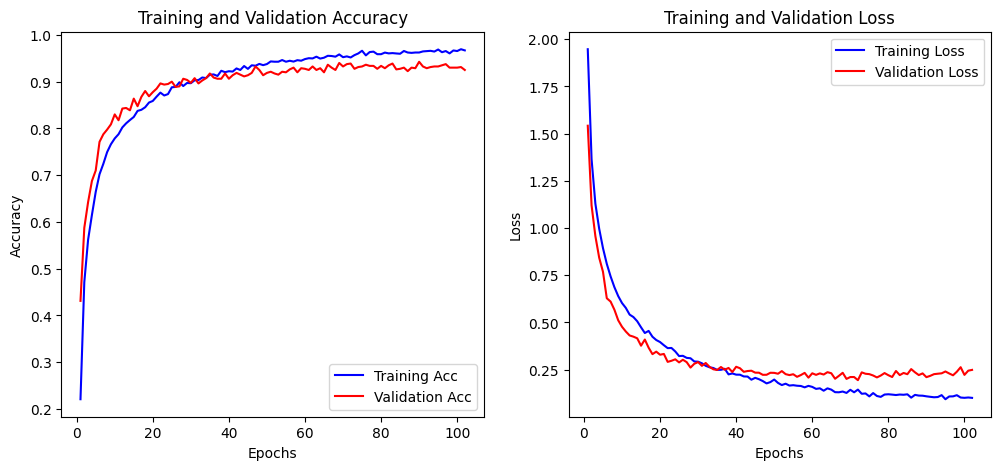

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, len(hist['loss']) + 1)

# 정확도(Accuracy) 그래프
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, hist.get('accuracy') or hist.get('acc'), 'b-', label='Training Acc')
plt.plot(epochs, hist.get('val_accuracy') or hist.get('val_acc'), 'r-', label='Validation Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실(Loss) 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, hist['loss'], 'b-', label='Training Loss')
plt.plot(epochs, hist['val_loss'], 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
